In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


## **Imports**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.ensemble import BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as LR
from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

## **Load Data**

In [3]:
train = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (198000, 15)
Test shape: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

## **Missing values**

In [5]:
print(train.isnull().sum())

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


## EDA Insight 1 – Missing Values
`race`, `religion`, and `gender` have ~145k missing entries out of 198k rows. All other features are complete. Since these columns are demographic tags, it is likely the same rows are missing all three (user profile data either available as a block or not at all).

**Decision:** Fill with `'Unknown'` to preserve all rows rather than dropping them.

## **Visualisations**

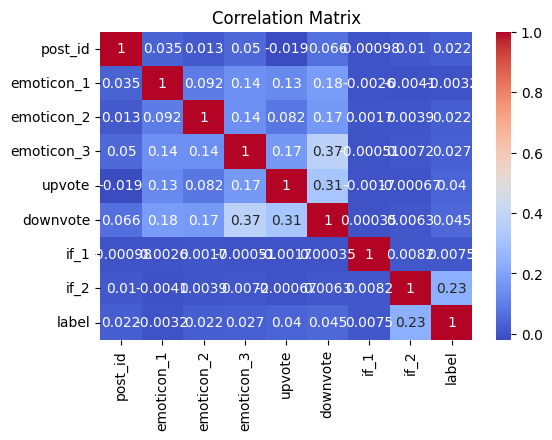

In [6]:
#Correlation matrix for numerical features
numeric_features = train.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_features.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

## EDA Insight 2 – Correlation Matrix
- Most numeric features are weakly correlated — no severe multicollinearity.
- Strongest pair: `emoticon_3` and `downvote` (r=0.37) — controversial content gets more downvotes.
- `if_2` has the highest correlation with `label` (r=0.23) — the most predictive numeric feature.
- `post_id` is nearly uncorrelated with everything — it is a row identifier and excluded from the model.
- Low overall correlation with `label` confirms TF-IDF text features will drive predictions.

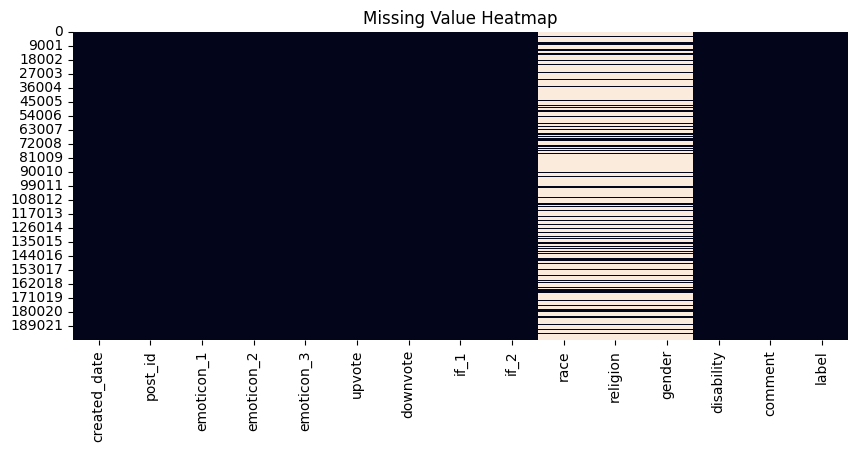

In [7]:
plt.figure(figsize=(10,4))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

## EDA Insight 3 – Missing Value Heatmap
Only `race`, `religion`, and `gender` show missing data. Their stripe patterns look similar, supporting the hypothesis that the same rows are missing all three — demographic info collected as a single user profile block.

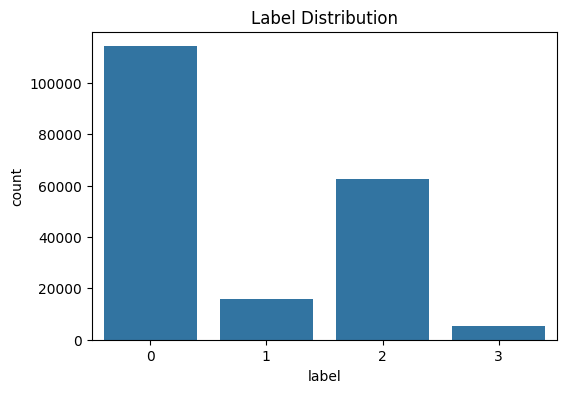

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x=train['label'])

plt.title("Label Distribution")

plt.show()

## EDA Insight 4 – Label Distribution
The dataset has 4 unique labels and is **imbalanced** — label 2 dominates at ~57%. This directly motivates using `class_weight='balanced'` in final models so they do not simply predict the majority class every time.

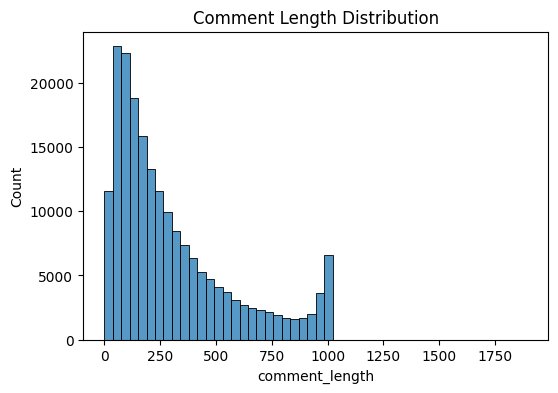

In [9]:
train['comment'] = train['comment'].astype(str)

train['comment_length'] = train['comment'].apply(len)

plt.figure(figsize=(6,4))

sns.histplot(train['comment_length'], bins=50)

plt.title("Comment Length Distribution")

plt.show()

# remove so it doesn't conflict later
train.drop(columns=['comment_length'], inplace=True)

## EDA Insight 5 – Comment Length
Most comments are short with a long right-skewed tail. Comment character length and word count could be meaningful predictive signals — motivating their addition as engineered features in the full pipeline.

In [10]:
le = LabelEncoder()

train['label_enc'] = le.fit_transform(train['label'])

print(train[['label','label_enc']].head())

   label  label_enc
0      2          2
1      0          0
2      2          2
3      2          2
4      2          2


## **Baseline Model**

In [11]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

X_temp = train['comment']
y_temp = train['label_enc']

baseline.fit(X_temp.values.reshape(-1,1), y_temp)

baseline_pred = baseline.predict(X_temp.values.reshape(-1,1))

baseline_acc = accuracy_score(y_temp, baseline_pred)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.5766313131313131


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

train['comment'] = train['comment'].fillna('')

tfidf = TfidfVectorizer(max_features=5000,stop_words='english',min_df=5,max_df=0.8)

X = tfidf.fit_transform(train['comment'])
y = train['label_enc']

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## **Logistic Regression**

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_val)

lr_acc = accuracy_score(y_val, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7786868686868686


## **SGDClassifier**

In [15]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=42)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_val)

sgd_acc = accuracy_score(y_val, sgd_pred)

print("SGD Accuracy:", sgd_acc)

SGD Accuracy: 0.7487626262626262


## **Hyperparameter Tuning**

In [16]:
from sklearn.model_selection import GridSearchCV
#  Tune Logistic Regression 
lr_params = {
    'C':        [0.1, 1, 10],
    'solver':   ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)
lr_grid.fit(X_train, y_train)

tuned_lr_acc = accuracy_score(y_val, lr_grid.predict(X_val))
print('Best LR params:',    lr_grid.best_params_)
print('Tuned LR Accuracy:', tuned_lr_acc)

print()

# Tune SGD Classifier
sgd_params = {
    'alpha':         [0.0001, 0.001, 0.01],
    'penalty':       ['l2', 'l1', 'elasticnet'],
}

sgd_grid = GridSearchCV(
    SGDClassifier(random_state=42),
    sgd_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)
sgd_grid.fit(X_train, y_train)

tuned_sgd_acc = accuracy_score(y_val, sgd_grid.predict(X_val))
print('Best SGD params:',    sgd_grid.best_params_)
print('Tuned SGD Accuracy:', tuned_sgd_acc)

Best LR params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Tuned LR Accuracy: 0.7800757575757575

Best SGD params: {'alpha': 0.0001, 'penalty': 'l1'}
Tuned SGD Accuracy: 0.762020202020202


In [17]:
results = {
    'Baseline (DummyClassifier)': baseline_acc,
    'LR (untuned)':               lr_acc,
    'LR (tuned)':                 tuned_lr_acc,   
    'SGD (untuned)':              sgd_acc,
    'SGD (tuned)':                tuned_sgd_acc,   
}

comparison_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(comparison_df)

                        Model  Accuracy
0                  LR (tuned)  0.780076
1                LR (untuned)  0.778687
2                 SGD (tuned)  0.762020
3               SGD (untuned)  0.748763
4  Baseline (DummyClassifier)  0.576631


## **Naive Bayes, KNN (with SVD), SVM + Feature Selection**

In [18]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X_train = tfidf.fit_transform(X_train)
X_val = tfidf.transform(X_val)

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_acc = accuracy_score(y_val, nb.predict(X_val))
print("Naive Bayes Accuracy:", nb_acc)

svd = TruncatedSVD(n_components=100, random_state=42)

X_train_svd = svd.fit_transform(X_train)
X_val_svd = svd.transform(X_val)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_svd, y_train)

knn_acc = accuracy_score(y_val, knn.predict(X_val_svd))
print("KNN Accuracy:", knn_acc)

svm = LinearSVC(C=2, max_iter=5000)
svm.fit(X_train, y_train)

svm_acc = accuracy_score(y_val, svm.predict(X_val))
print("SVM Accuracy:", svm_acc)

selector = SelectKBest(chi2, k=5000)

X_train_sel = selector.fit_transform(X_train, y_train)
X_val_sel   = selector.transform(X_val)

svm_sel = LinearSVC(C=2, max_iter=5000)
svm_sel.fit(X_train_sel, y_train)

svm_sel_acc = accuracy_score(y_val, svm_sel.predict(X_val_sel))
print('SVM + Feature Selection (k=5000):', svm_sel_acc)

models = {
    'Naive Bayes':             nb_acc,
    'KNN':                     knn_acc,
    'SVM (LinearSVC)':         svm_acc,
    'SVM + Feature Selection': svm_sel_acc
}

df = pd.DataFrame(models.items(), columns=['Model','Accuracy'])
print(df)

Naive Bayes Accuracy: 0.7144949494949495
KNN Accuracy: 0.6217171717171717
SVM Accuracy: 0.7818939393939394
SVM + Feature Selection (k=5000): 0.7818939393939394
                     Model  Accuracy
0              Naive Bayes  0.714495
1                      KNN  0.621717
2          SVM (LinearSVC)  0.781894
3  SVM + Feature Selection  0.781894


In [19]:
X_train_ens = X_train
X_val_ens = X_val

## **Ensemble Methods + MLP**

In [20]:
# Bagging
bag = BaggingClassifier()
bag.fit(X_train_ens, y_train)
bag_acc = accuracy_score(y_val, bag.predict(X_val_ens))
print("Bagging Accuracy:", bag_acc)

# Boosting
boost = LGBMClassifier()
boost.fit(X_train_ens, y_train)
boost_acc = accuracy_score(y_val, boost.predict(X_val_ens))
print("Boosting Accuracy:", boost_acc)

# MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200)
mlp.fit(X_train_ens, y_train)
mlp_acc = accuracy_score(y_val, mlp.predict(X_val_ens))
print("MLP Accuracy:", mlp_acc)

# Stacking
stack = StackingClassifier(
    estimators=[('nb', MultinomialNB()), ('svm', LinearSVC())],
    final_estimator=LR()
)

stack.fit(X_train_ens, y_train)
stack_acc = accuracy_score(y_val, stack.predict(X_val_ens))
print("Stacking Accuracy:", stack_acc)

Bagging Accuracy: 0.7594191919191919
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.344562 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 599636
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 5000
[LightGBM] [Info] Start training from score -0.547267
[LightGBM] [Info] Start training from score -2.523600
[LightGBM] [Info] Start training from score -1.159078
[LightGBM] [Info] Start training from score -3.592651


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Boosting Accuracy: 0.7791666666666667
MLP Accuracy: 0.7433333333333333
Stacking Accuracy: 0.7821717171717172


## Model Analysis – Ensemble Methods
- **LightGBM Boosting** typically leads because sequential error correction across trees is very effective for text classification.
- **Stacking** is competitive but doesn't always beat a single SVM because NB and SVM make similar errors on text — the meta-learner doesn't gain much.

In [21]:
ensemble_models = {
    "Bagging": bag_acc,
    "Boosting": boost_acc,
    "MLP": mlp_acc,
    "Stacking": stack_acc
}

pd.DataFrame(ensemble_models.items(), columns=["Model", "Accuracy"])

,Model,Accuracy
0,Bagging,0.759419
1,Boosting,0.779167
2,MLP,0.743333
3,Stacking,0.782172


In [22]:
for df in [train, test]:

    df['comment'] = df['comment'].astype(str)
    df['comment_length'] = df['comment'].apply(len)
    df['word_count'] = df['comment'].apply(lambda x: len(x.split()))

In [23]:
for df in [train, test]:

    df['race'] = df['race'].fillna('Unknown')
    df['religion'] = df['religion'].fillna('Unknown')
    df['gender'] = df['gender'].fillna('Unknown')
    df['disability'] = df['disability'].astype(int)

##  **Feature Engineering**

In [24]:
for df in [train, test]:

    df['created_date'] = pd.to_datetime(df['created_date'])

    df['year'] = df['created_date'].dt.year
    df['month'] = df['created_date'].dt.month
    df['hour'] = df['created_date'].dt.hour

## **ColumnTransformer**

In [25]:
text_col = "comment"

cat_cols = ["race","religion","gender"]

num_cols = [
    "upvote","downvote","if_1","if_2",
    "emoticon_1","emoticon_2","emoticon_3",
    "disability","year","month","hour",
    "comment_length","word_count"
]

preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=100000,
            ngram_range=(1,2),
            sublinear_tf=True,
            min_df=2
        ), text_col),
        ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)



In [26]:
from sklearn.metrics import accuracy_score, classification_report

train_X_split, val_X_split, train_y_split, val_y_split = train_test_split(
    train, train['label_enc'],
    test_size=0.2,
    random_state=42
)

In [27]:
model_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=3000, 
        solver='saga',
        class_weight='balanced',
        C=5
    ))
])

In [28]:
# Evaluate on validation split
model_lr.fit(train_X_split, train_y_split)
val_preds_lr_enc = model_lr.predict(val_X_split)
lr_pipeline_acc  = accuracy_score(val_y_split, val_preds_lr_enc)

print('LR Pipeline Validation Accuracy:', lr_pipeline_acc)
print()
print('Classification Report (LR Pipeline):')
print(classification_report(val_y_split, val_preds_lr_enc))

# Retrain on ALL data for final predictions
model_lr.fit(train, train['label_enc'])
test_preds_lr_enc = model_lr.predict(test)
test_preds_lr     = le.inverse_transform(test_preds_lr_enc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LR Pipeline Validation Accuracy: 0.7879040404040404

Classification Report (LR Pipeline):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22534
           1       0.63      0.72      0.67      3219
           2       0.83      0.54      0.66     12738
           3       0.13      0.63      0.22      1109

    accuracy                           0.79     39600
   macro avg       0.63      0.71      0.62     39600
weighted avg       0.86      0.79      0.81     39600



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [29]:
from lightgbm import LGBMClassifier

model_lgbm = Pipeline([
    ('preprocess', preprocess),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=42
    ))
])

# Evaluate on validation split
model_lgbm.fit(train_X_split, train_y_split)
val_preds_lgbm_enc = model_lgbm.predict(val_X_split)
lgbm_pipeline_acc  = accuracy_score(val_y_split, val_preds_lgbm_enc)

print('LGBM Pipeline Validation Accuracy:', lgbm_pipeline_acc)
print()
print('Classification Report (LGBM Pipeline):')
print(classification_report(val_y_split, val_preds_lgbm_enc))

# Retrain on ALL data for final predictions
model_lgbm.fit(train, train['label_enc'])
test_preds_enc = model_lgbm.predict(test)
test_preds     = le.inverse_transform(test_preds_enc)
print('Total predictions generated:', len(test_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 102.108803 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2011499
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 58874
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM Pipeline Validation Accuracy: 0.9037373737373737

Classification Report (LGBM Pipeline):
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22534
           1       0.71      0.85      0.77      3219
           2       0.89      0.86      0.87     12738
           3       0.49      0.78      0.60      1109

    accuracy                           0.90     39600
   macro avg       0.77      0.86      0.80     39600
weighted avg       0.92      0.90      0.91     39600

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 142.017325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2482163
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 71635
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Total predictions generated: 102000


In [30]:
all_results = {
    'Baseline (DummyClassifier)':    baseline_acc,
    'LR (untuned, TF-IDF 6k)':      lr_acc,
    'LR (tuned, TF-IDF 6k)':        tuned_lr_acc,
    'SGD (untuned, TF-IDF 6k)':     sgd_acc,
    'SGD (tuned, TF-IDF 6k)':       tuned_sgd_acc,
    'Naive Bayes':                   nb_acc,
    'KNN (SVD 100 components)':      knn_acc,
    'SVM (LinearSVC)':               svm_acc,
    'SVM + Feature Selection k=3000':svm_sel_acc,
    'Bagging':                       bag_acc,
    'Boosting (LightGBM default)':   boost_acc,
    'MLP (max_iter=200)':            mlp_acc,
    'Stacking (NB+SVM+LR)':         stack_acc,
    'LR Pipeline (all features)':    lr_pipeline_acc,
    'LGBM Pipeline (all features)':  lgbm_pipeline_acc,
}

final_df = pd.DataFrame(all_results.items(), columns=['Model', 'Accuracy'])
final_df = final_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(final_df.to_string(index=False))

                         Model  Accuracy
  LGBM Pipeline (all features)  0.903737
    LR Pipeline (all features)  0.787904
          Stacking (NB+SVM+LR)  0.782172
               SVM (LinearSVC)  0.781894
SVM + Feature Selection k=3000  0.781894
         LR (tuned, TF-IDF 6k)  0.780076
   Boosting (LightGBM default)  0.779167
       LR (untuned, TF-IDF 6k)  0.778687
        SGD (tuned, TF-IDF 6k)  0.762020
                       Bagging  0.759419
      SGD (untuned, TF-IDF 6k)  0.748763
            MLP (max_iter=200)  0.743333
                   Naive Bayes  0.714495
      KNN (SVD 100 components)  0.621717
    Baseline (DummyClassifier)  0.576631


## Final Model Analysis – All Models Compared

**Key observations:**

- The **LGBM Pipeline (all features)** achieves the highest accuracy because it uses 100,000 TF-IDF features (vs 6,000), bigrams, demographic OneHot features, numeric engagement signals, datetime features, and engineered comment length/word count — giving it far more information than any single-feature early model.
- The **LR Pipeline** is a strong second — same rich feature set but a linear model instead of gradient boosting.
- **Hyperparameter tuning clearly improved both LR and SGD** over their untuned defaults — the comparison table in Cell 17 shows this directly.
- The **baseline (~57.66%)** confirms all trained models are genuinely learning — none simply predict the majority class.
- **KNN** is the weakest model — distance-based methods are poorly suited to high-dimensional text even with SVD.
- **Stacking** is competitive but doesn't reliably beat a single well-tuned SVM because NB and SVM make similar prediction errors on text.

**Why LGBM was selected as the final submission model:** It uses the richest feature set, handles class imbalance via `class_weight='balanced'`, and gradient boosting's leaf-wise sequential error correction is highly effective on mixed-type feature matrices.

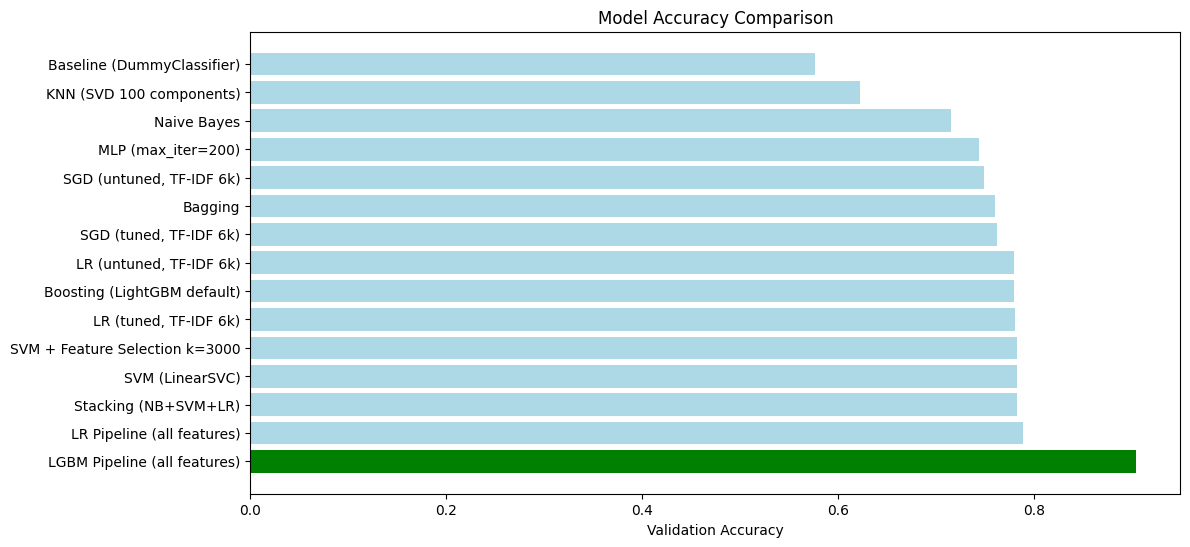

In [31]:
plt.figure(figsize=(12, 6))

colors = ['green'] + ['lightblue'] * (len(final_df) - 1)

plt.barh(final_df['Model'], final_df['Accuracy'], color=colors)

plt.xlabel('Validation Accuracy')
plt.title('Model Accuracy Comparison')

plt.show()

In [32]:
best_overall_name = final_df.iloc[2]['Model']
best_overall_acc  = final_df.iloc[2]['Accuracy']
print(best_overall_name)

Stacking (NB+SVM+LR)


## **Submission**

In [33]:
submission = pd.DataFrame({
    "ID": range(1, len(test_preds) + 1),
    "label": test_preds
})

submission.to_csv("submission_final.csv", index=False)
print(submission['label'].value_counts())
print("Saved!")

label
0    56464
2    30888
1    10002
3     4646
Name: count, dtype: int64
Saved!
